<a href="https://colab.research.google.com/github/mk-the-ish/mk-the-ish/blob/main/Zimbabwe_Optimal_Route_Finder_for_Jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import heapq
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

In [2]:
# =============================================================================
# 1. GRAPH DATA REPRESENTATION (Weighted Edges: Distance in km)
# =============================================================================

# Major cities in Zimbabwe
CITIES = [
    "Harare", "Bulawayo", "Gweru", "Mutare", "Chinhoyi", "Masvingo",
    "Beitbridge", "Vic Falls"
]
CITY_MAP = {city: i for i, city in enumerate(CITIES)}
N_TOTAL = len(CITIES)
INF = float('inf')

In [3]:
# Geographical Coordinates (Rough estimates for visualization layout)
CITY_POSITIONS = {
    "Harare": (31.0, -17.8),
    "Bulawayo": (28.6, -20.2),
    "Gweru": (29.8, -19.4),
    "Mutare": (32.6, -18.9),
    "Chinhoyi": (30.1, -17.4),
    "Masvingo": (30.8, -20.0),
    "Beitbridge": (30.0, -22.2),
    "Vic Falls": (25.8, -17.9),
}

In [4]:
# Road Network Data (Undirected: City1, City2, Distance_km)
ROAD_NETWORK_DATA = [
    ("Harare", "Bulawayo", 439),
    ("Harare", "Gweru", 275),
    ("Harare", "Mutare", 263),
    ("Harare", "Chinhoyi", 115),
    ("Harare", "Masvingo", 292),
    ("Harare", "Beitbridge", 580),
    ("Harare", "Vic Falls", 878),

    ("Bulawayo", "Gweru", 164),
    ("Bulawayo", "Mutare", 577),
    ("Bulawayo", "Chinhoyi", 425),
    ("Bulawayo", "Masvingo", 280),
    ("Bulawayo", "Beitbridge", 321),
    ("Bulawayo", "Vic Falls", 439),

    ("Gweru", "Mutare", 405),
    ("Gweru", "Chinhoyi", 261),
    ("Gweru", "Masvingo", 164),
    ("Gweru", "Beitbridge", 403),
    ("Gweru", "Vic Falls", 603),

    ("Mutare", "Chinhoyi", 378),
    ("Mutare", "Masvingo", 297),
    ("Mutare", "Beitbridge", 585),
    ("Mutare", "Vic Falls", 1016),

    ("Chinhoyi", "Masvingo", 407),
    ("Chinhoyi", "Beitbridge", 664),
    ("Chinhoyi", "Vic Falls", 864),

    ("Masvingo", "Beitbridge", 288),
    ("Masvingo", "Vic Falls", 719),

    ("Beitbridge", "Vic Falls", 760),
]

In [5]:
# Building Adjacency List
ADJACENCY_LIST = defaultdict(list)
for c1, c2, dist in ROAD_NETWORK_DATA:
    ADJACENCY_LIST[c1].append((c2, dist))
    ADJACENCY_LIST[c2].append((c1, dist))

In [6]:
# =============================================================================
# 2. ALGORITHM IMPLEMENTATIONS
# =============================================================================

class ZimbabweRouter:
    """
    Handles graph operations and shortest path/TSP calculations.
    Initializes by pre-computing all-pairs shortest paths using Dijkstra's.
    """

    def __init__(self, cities, city_map, adj_list):
        self.cities = cities
        self.city_map = city_map
        self.adj_list = adj_list
        self.N_TOTAL = len(cities)
        self.INF = float('inf')
        # Distance matrix stores shortest distance between any two cities
        self.dist_matrix = [[self.INF] * self.N_TOTAL for _ in range(self.N_TOTAL)]

        self._precompute_all_shortest_paths()

    def _precompute_all_shortest_paths(self):
        """
        Runs Dijkstra's from every city to fill the distance matrix.
        This is crucial for the TSP implementation.
        """
        print("Router initialized. Pre-computing all-pairs shortest paths...")
        for i, start_city in enumerate(self.cities):
            distances, _ = self.dijkstra(start_city)
            for end_city, dist in distances.items():
                j = self.city_map[end_city]
                self.dist_matrix[i][j] = dist
        print("Pre-computation complete.")

    def dijkstra(self, start_city, end_city=None):
        """
        Finds the shortest path from start_city to all other nodes
        (or specifically to end_city) using Dijkstra's algorithm.
        Returns distances dictionary and predecessors dictionary.
        """
        if start_city not in self.city_map:
            raise ValueError(f"Error: City '{start_city}' not found.")

        distances = {city: self.INF for city in self.cities}
        distances[start_city] = 0
        predecessors = {city: None for city in self.cities}
        pq = [(0, start_city)] # (distance, city_name)

        while pq:
            current_dist, u_city = heapq.heappop(pq)
            if current_dist > distances[u_city]: continue

            if end_city and u_city == end_city: break

            for v_city, weight in self.adj_list.get(u_city, []):
                new_dist = current_dist + weight
                if new_dist < distances[v_city]:
                    distances[v_city] = new_dist
                    predecessors[v_city] = u_city
                    heapq.heappush(pq, (new_dist, v_city))

        return distances, predecessors

    def reconstruct_path(self, start_city, end_city, predecessors):
        """Reconstructs the shortest path from predecessors dictionary."""
        path = []
        current = end_city
        while current is not None:
            path.append(current)
            current = predecessors.get(current)
            if current == start_city:
                path.append(start_city)
                break
            # Handle unreachable paths
            if current is None and end_city != start_city and path[-1] != start_city:
                return ["Path not found or unreachable."]

        return path[::-1] # Reverse to get start -> end

    def solve_tsp_for_subset(self, cities_to_visit: list[str]):
        """
        Solves the Traveling Salesman Problem (TSP) using Held-Karp Dynamic
        Programming for a specified subset of cities. The circuit starts and
        ends at the first city in the list.
        Returns total distance and the full detailed route.
        """

        N_sub = len(cities_to_visit)
        if N_sub < 2:
            return 0, cities_to_visit

        # 1. Create mapping from subset city names to full graph index and DP index
        subset_to_full_index = [self.city_map[city] for city in cities_to_visit]
        start_city = cities_to_visit[0]
        start_dp_index = 0

        # DP table: (mask, j) -> min_cost (j is DP index)
        dp = {}
        # Path table: (mask, j) -> previous_dp_city_index
        path_predecessor = {}

        # Base case
        initial_mask = 1 << start_dp_index
        dp[(initial_mask, start_dp_index)] = 0

        # Held-Karp DP loop
        for mask in range(1, 1 << N_sub):
            if not (mask & initial_mask): continue
            for j_dp in range(N_sub):
                if not (mask & (1 << j_dp)): continue
                if j_dp == start_dp_index and mask != initial_mask: continue

                prev_mask = mask ^ (1 << j_dp)
                j_full = subset_to_full_index[j_dp]

                for k_dp in range(N_sub):
                    if k_dp == j_dp or not (prev_mask & (1 << k_dp)): continue

                    k_full = subset_to_full_index[k_dp]
                    cost_k_to_j = self.dist_matrix[k_full][j_full]

                    if (prev_mask, k_dp) in dp:
                        new_cost = dp[(prev_mask, k_dp)] + cost_k_to_j
                        current_min_cost = dp.get((mask, j_dp), self.INF)

                        if new_cost < current_min_cost:
                            dp[(mask, j_dp)] = new_cost
                            path_predecessor[(mask, j_dp)] = k_dp

        # Final Step: Return to start
        final_mask = (1 << N_sub) - 1
        min_tsp_cost = self.INF
        last_city_dp_index = -1

        for j_dp in range(N_sub):
            if j_dp == start_dp_index: continue

            j_full = subset_to_full_index[j_dp]
            start_full = subset_to_full_index[start_dp_index]

            cost_j_to_start = self.dist_matrix[j_full][start_full]

            if (final_mask, j_dp) in dp:
                total_cost = dp[(final_mask, j_dp)] + cost_j_to_start

                if total_cost < min_tsp_cost:
                    min_tsp_cost = total_cost
                    last_city_dp_index = j_dp

        # Reconstruct the Full TSP Path
        tsp_path_dp_indices = []
        if min_tsp_cost != self.INF:
            current_dp_index = last_city_dp_index
            current_mask = final_mask

            # Step 1: Reconstruct the sequence of mandatory cities
            while current_mask != initial_mask:
                tsp_path_dp_indices.append(current_dp_index)
                prev_dp_index = path_predecessor.get((current_mask, current_dp_index))
                if prev_dp_index is None: return min_tsp_cost, []

                current_mask = current_mask ^ (1 << current_dp_index)
                current_dp_index = prev_dp_index

            tsp_path_dp_indices.append(start_dp_index)

            mandatory_city_path = [cities_to_visit[i] for i in tsp_path_dp_indices[::-1]]
            mandatory_city_path.append(start_city) # Complete the cycle

            # Step 2: Reconstruct the full path including intermediate hops
            full_tsp_route = []
            for i in range(len(mandatory_city_path) - 1):
                c_start = mandatory_city_path[i]
                c_end = mandatory_city_path[i+1]

                # Get the detailed shortest path between these two mandatory stops
                _, predecessors = self.dijkstra(c_start, c_end)
                segment = self.reconstruct_path(c_start, c_end, predecessors)

                if full_tsp_route:
                    # Skip the start city of the new segment to avoid duplication
                    full_tsp_route.extend(segment[1:])
                else:
                    full_tsp_route.extend(segment)

            return min_tsp_cost, full_tsp_route, mandatory_city_path

        return self.INF, [], [] # No path found

In [7]:
# =============================================================================
# 3. VISUALIZATION
# =============================================================================

def create_graph(road_data):
    """Creates a NetworkX graph object from the road data."""
    G = nx.Graph()
    for c1, c2, dist in road_data:
        G.add_edge(c1, c2, weight=dist)
    return G

In [8]:
def visualize_route(G, pos, path, title, total_distance):
    """Draws the graph and highlights a specific path (Dijkstra or TSP)."""

    plt.figure(figsize=(12, 9))
    plt.title(f"{title}\nTotal Distance: {total_distance:.2f} km", fontsize=14)

    # 1. Draw all nodes and edges (base network)
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=600)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    all_edges = [(u, v) for u, v, d in G.edges(data=True)]
    nx.draw_networkx_edges(G, pos, edgelist=all_edges, edge_color='gray', style='dashed', alpha=0.5, width=1)

    # Draw edge labels (distances)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    # Use a smaller font for dense labels
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='darkgray', font_size=6.5)

    # 2. Identify the path edges to highlight
    path_edges = []

    for i in range(len(path) - 1):
        u, v = path[i], path[i+1]
        # NetworkX is undirected, append the edge tuple in canonical order
        edge = tuple(sorted((u, v)))
        path_edges.append(edge)

    # Remove duplicates from path_edges
    path_edges = list(set(path_edges))

    # 3. Highlight the path

    # Highlight Path Edges (thick and red)
    nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#E91E63', width=3, style='solid')

    # Highlight Start/End Nodes
    start_node = path[0]
    end_node = path[-1]

    # Draw Start Node (Green)
    nx.draw_networkx_nodes(G, pos, nodelist=[start_node], node_color='#4CAF50', node_size=700, edgecolors='black', linewidths=1.5)

    # Draw End Node (Blue, or Green if TSP cycle)
    if start_node != end_node:
         nx.draw_networkx_nodes(G, pos, nodelist=[end_node], node_color='#2196F3', node_size=700, edgecolors='black', linewidths=1.5)

    # Highlight Intermediate Hops (Orange)
    # Exclude the exact start and end nodes from the intermediate visualization
    intermediate_nodes = [node for node in path[1:-1] if node != start_node and node != end_node]
    nx.draw_networkx_nodes(G, pos, nodelist=intermediate_nodes, node_color='#FF9800', node_size=650, edgecolors='black', linewidths=1.0)

    # Create simple legend
    plt.plot([], [], 'o', color='#4CAF50', markeredgecolor='black', markersize=10, label='Start')
    if start_node != end_node:
        plt.plot([], [], 'o', color='#2196F3', markeredgecolor='black', markersize=10, label='End')
    plt.plot([], [], 'o', color='#FF9800', markeredgecolor='black', markersize=9, label='Intermediate Hop')

    plt.legend(loc='upper right', frameon=False)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('off') # Turn off axes for a cleaner map look
    plt.tight_layout()
    plt.show()

In [9]:
# =============================================================================
# 4. NOTEBOOK-FRIENDLY WRAPPER FUNCTIONS
# =============================================================================

def find_shortest_path_and_plot(router: ZimbabweRouter, start: str, end: str, max_distance: float = INF):
    """
    Finds the shortest path, prints results, and visualizes the route.
    Designed for easy use in a Jupyter Notebook cell.
    """
    if start not in CITIES or end not in CITIES:
        print(f"Error: Start or end city not valid. Available cities: {', '.join(CITIES)}")
        return

    print(f"--- Shortest Path: {start} to {end} ---")

    distances, predecessors = router.dijkstra(start, end)
    shortest_path = router.reconstruct_path(start, end, predecessors)
    total_dist = distances.get(end, INF)

    if total_dist == INF:
        print("Path not found.")
        return

    print(f"Path: {' -> '.join(shortest_path)}")
    print(f"Total Distance: {total_dist:.2f} km")

    if total_dist > max_distance:
        print(f"Constraint breached: Total distance EXCEEDS the maximum allowed of {max_distance:.2f} km.")
    else:
        G = create_graph(ROAD_NETWORK_DATA)
        visualize_route(G, CITY_POSITIONS, shortest_path,
                        f"Shortest Path: {start} to {end}", total_dist)

In [10]:
def find_tsp_tour_and_plot(router: ZimbabweRouter, mandatory_cities: list[str]):
    """
    Finds the optimal Traveling Salesman Tour for a subset of cities,
    prints results, and visualizes the route.
    The tour always starts and ends at the first city in the list.
    """
    # Simple validation
    if not mandatory_cities or len(mandatory_cities) < 2:
        print("Error: You must provide at least two cities for a meaningful TSP.")
        return

    for city in mandatory_cities:
        if city not in CITIES:
            print(f"Error: City '{city}' is not valid. Available cities: {', '.join(CITIES)}")
            return

    start_city = mandatory_cities[0]
    intermediate_stops = [c for c in mandatory_cities[1:]]

    print(f"\n--- TSP Tour: Visiting {', '.join(mandatory_cities)} ---")
    print(f"Start/End City: {start_city}")

    # Solve TSP
    min_tsp_cost, full_tsp_route, mandatory_city_path = router.solve_tsp_for_subset(mandatory_cities)

    if min_tsp_cost == INF:
        print("TSP solution could not be found, likely due to a disconnected subset.")
        return

    print(f"Optimal Visit Order: {' -> '.join(mandatory_city_path)}")
    print(f"Total Minimum Distance: {min_tsp_cost:.2f} km")

    # Visualize
    G = create_graph(ROAD_NETWORK_DATA)
    title = f"Optimal TSP Tour ({len(mandatory_cities)} Cities)"
    visualize_route(G, CITY_POSITIONS, full_tsp_route, title, min_tsp_cost)

In [12]:
# =============================================================================
# 5. NOTEBOOK EXECUTION EXAMPLES
# =============================================================================
router = ZimbabweRouter(CITIES, CITY_MAP, ADJACENCY_LIST)

Router initialized. Pre-computing all-pairs shortest paths...
Pre-computation complete.


--- 1A: Shortest Path Example (Harare to Vic Falls) ---
--- Shortest Path: Harare to Vic Falls ---
Path: Harare -> Vic Falls
Total Distance: 878.00 km


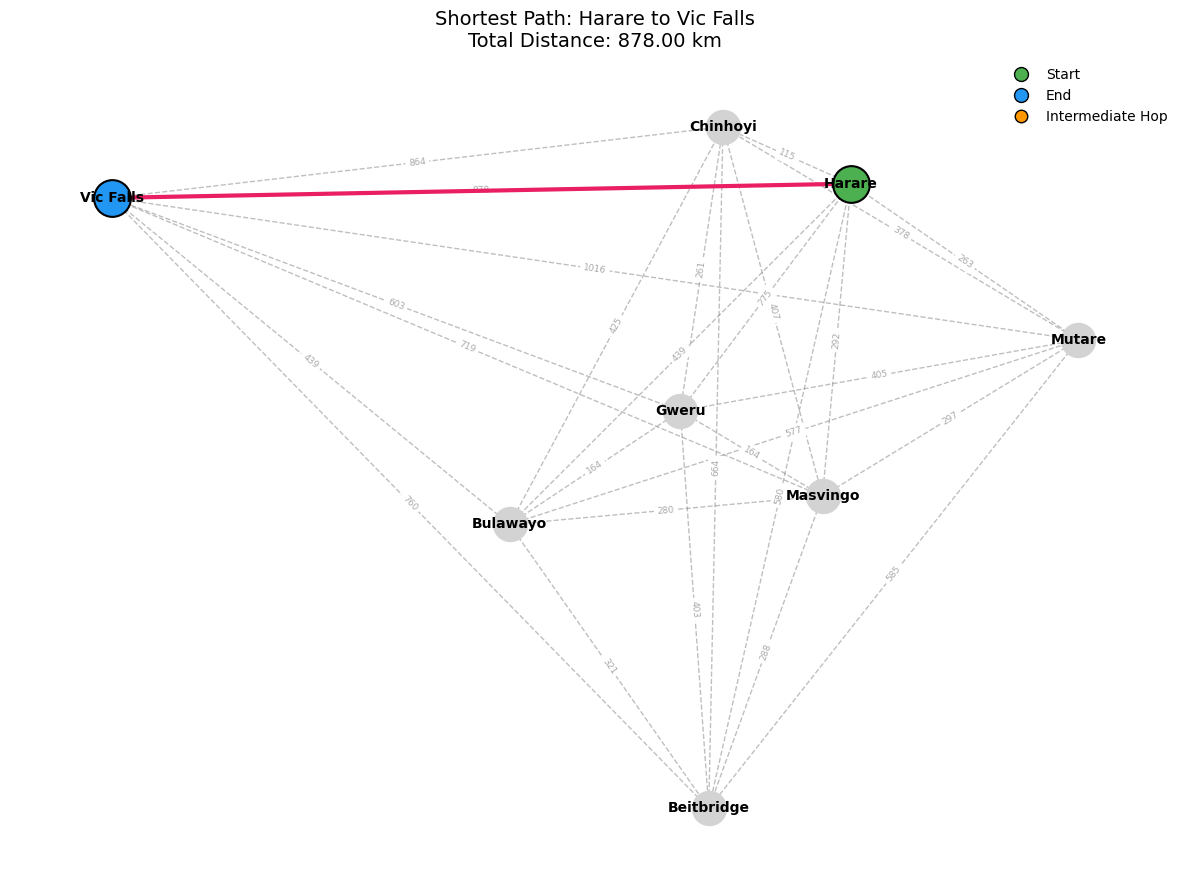

In [13]:
# --- Example 1: Standard Shortest Path ---
print("--- 1A: Shortest Path Example (Harare to Vic Falls) ---")
find_shortest_path_and_plot(router, start="Harare", end="Vic Falls")

In [14]:
# --- Example 2: Shortest Path with Max Distance Constraint ---
print("\n--- 1B: Shortest Path with Constraint (Harare to Masvingo, Max 250km) ---")
find_shortest_path_and_plot(router, start="Harare", end="Masvingo", max_distance=250)


--- 1B: Shortest Path with Constraint (Harare to Masvingo, Max 250km) ---
--- Shortest Path: Harare to Masvingo ---
Path: Harare -> Masvingo
Total Distance: 292.00 km
Constraint breached: Total distance EXCEEDS the maximum allowed of 250.00 km.



--- 2A: TSP Tour Example (Harare -> Gweru -> Bulawayo -> Harare) ---

--- TSP Tour: Visiting Harare, Gweru, Bulawayo ---
Start/End City: Harare
Optimal Visit Order: Harare -> Bulawayo -> Gweru -> Harare
Total Minimum Distance: 878.00 km


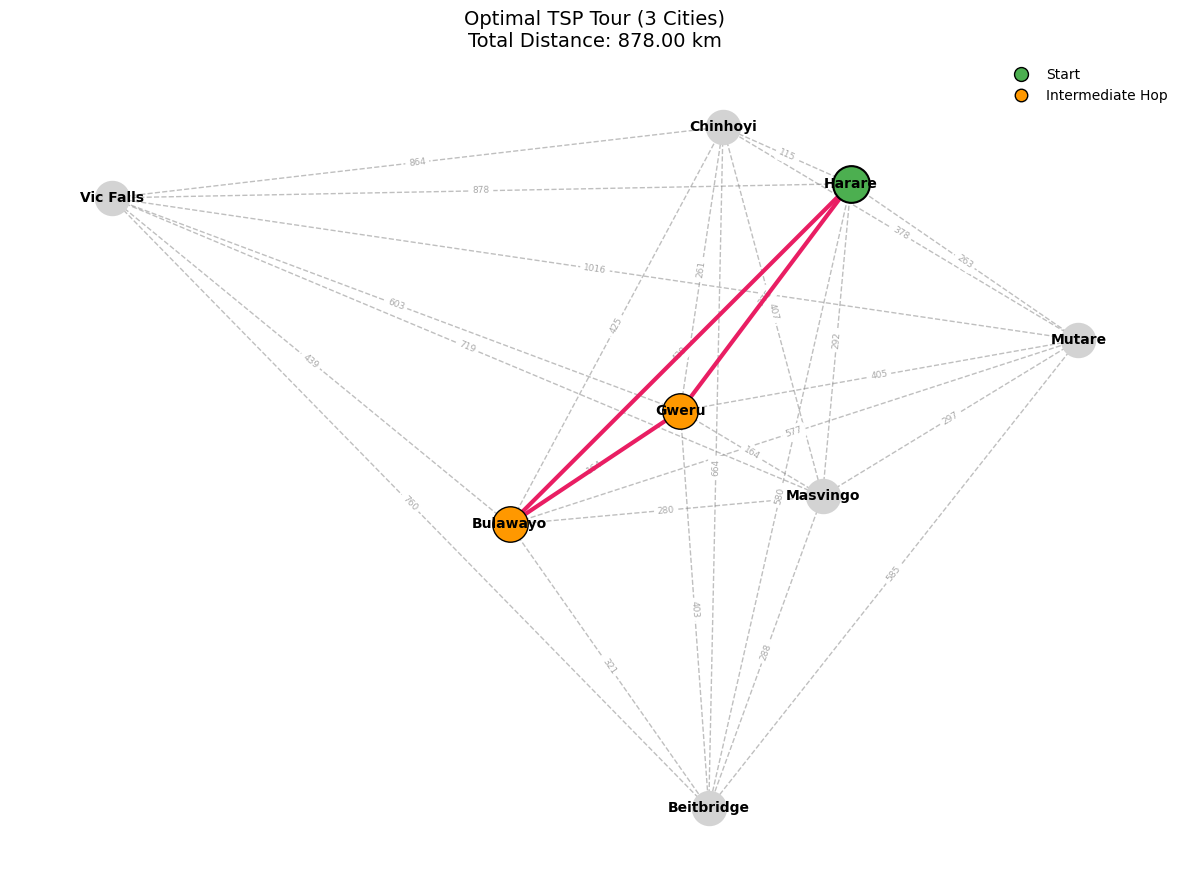

In [15]:
# --- Example 3: TSP for a Subset of Cities ---
print("\n--- 2A: TSP Tour Example (Harare -> Gweru -> Bulawayo -> Harare) ---")
find_tsp_tour_and_plot(router, mandatory_cities=["Harare", "Gweru", "Bulawayo"])


--- 2B: Full TSP Tour Example (All 8 Cities) ---

--- TSP Tour: Visiting Harare, Bulawayo, Gweru, Mutare, Chinhoyi, Masvingo, Beitbridge, Vic Falls ---
Start/End City: Harare
Optimal Visit Order: Harare -> Chinhoyi -> Gweru -> Vic Falls -> Bulawayo -> Beitbridge -> Masvingo -> Mutare -> Harare
Total Minimum Distance: 2587.00 km


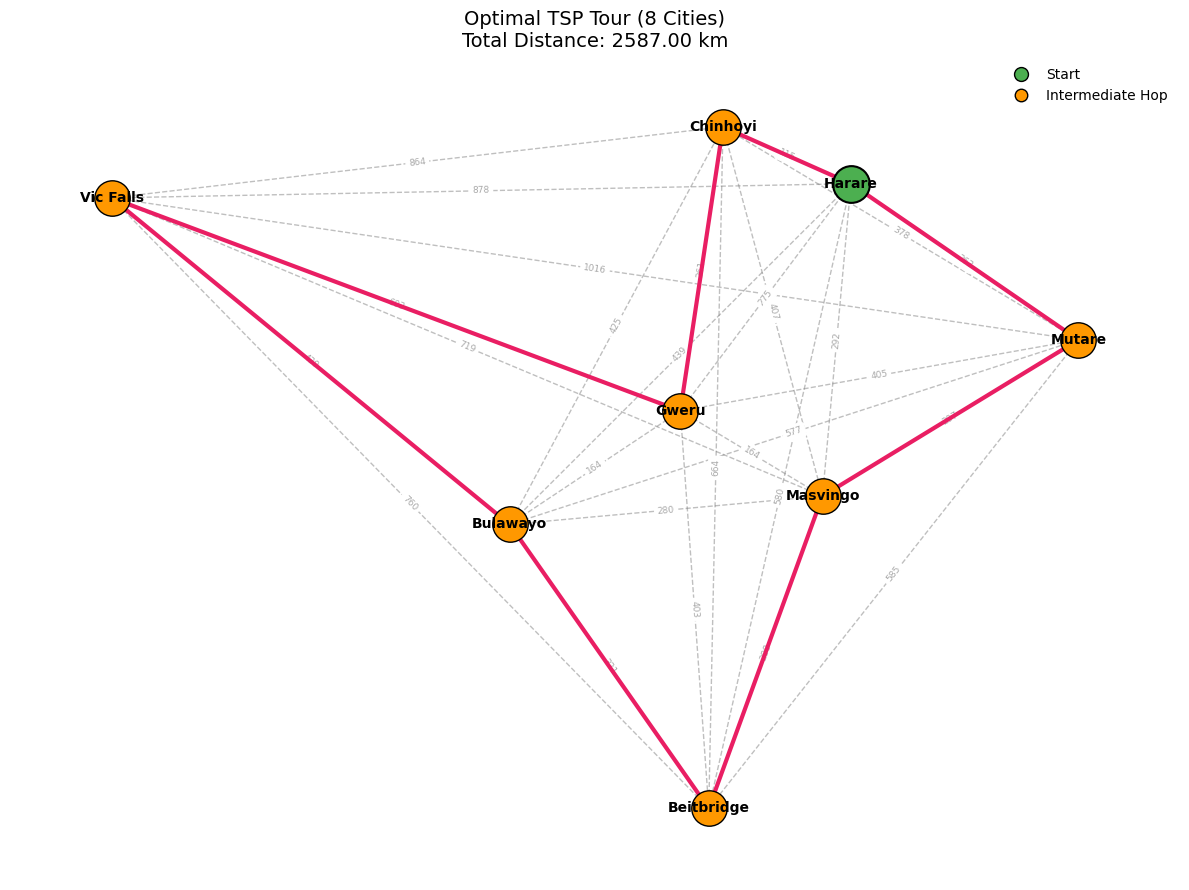

In [16]:
# --- Example 4: Full TSP (visiting all cities) ---
print("\n--- 2B: Full TSP Tour Example (All 8 Cities) ---")
find_tsp_tour_and_plot(router, mandatory_cities=CITIES)